# pyapr Smoke Test
Quick end-to-end test of the main pyapr functions using a synthetic 3D image.

## 1. Import

In [1]:
import tempfile, os
import numpy as np
import pyapr

print(f"pyapr version : {pyapr.__version__}")
print(f"CUDA enabled  : {pyapr.cuda_enabled()}")

pyapr version : 1.0.8.dev1+g545b817f4
CUDA enabled  : False


## 2. Synthetic image

In [2]:
rng = np.random.default_rng(0)
img = rng.integers(0, 1000, size=(64, 64, 64), dtype=np.uint16)
print(f"shape={img.shape}  dtype={img.dtype}  min={img.min()}  max={img.max()}")

shape=(64, 64, 64)  dtype=uint16  min=0  max=999


## 3. APR conversion

In [3]:
apr, parts = pyapr.converter.get_apr(img)
print(f"total particles    : {apr.total_number_particles()}")
print(f"computational ratio: {apr.computational_ratio():.2f}")

total particles    : 140120
computational ratio: 1.87


## 4. Fill tree

In [4]:
pyapr.tree.fill_tree_mean(apr, parts)
print(f"parts size after fill_tree_mean: {len(parts)}")

parts size after fill_tree_mean: 140120


## 5. Reconstruction

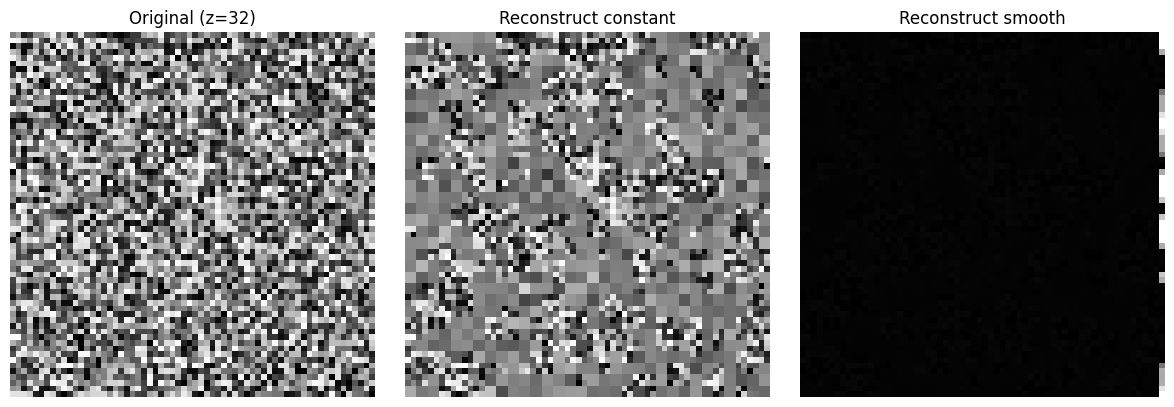

recon_const shape : (64, 64, 64)
recon_smooth shape: (64, 64, 64)


In [5]:
import matplotlib.pyplot as plt

recon_const  = pyapr.reconstruction.reconstruct_constant(apr, parts)
recon_smooth = pyapr.reconstruction.reconstruct_smooth(apr, parts)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img[32],          cmap='gray'); axes[0].set_title('Original (z=32)')
axes[1].imshow(recon_const[32],  cmap='gray'); axes[1].set_title('Reconstruct constant')
axes[2].imshow(recon_smooth[32], cmap='gray'); axes[2].set_title('Reconstruct smooth')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print(f"recon_const shape : {recon_const.shape}")
print(f"recon_smooth shape: {recon_smooth.shape}")

## 6. Filters

In [6]:
fparts = pyapr.FloatParticles(parts[:].astype(np.float32))

grad    = pyapr.filter.gradient(apr, fparts, dim=0)
gm      = pyapr.filter.gradient_magnitude(apr, fparts)
stencil = pyapr.filter.get_gaussian_stencil(size=3, sigma=1.0, ndims=3, normalize=True)
smoothed = pyapr.filter.convolve(apr, fparts, stencil)

print(f"gradient len          : {len(grad)}")
print(f"gradient_magnitude len: {len(gm)}")
print(f"smoothed len          : {len(smoothed)}")

gradient len          : 140120
gradient_magnitude len: 140120
smoothed len          : 140120


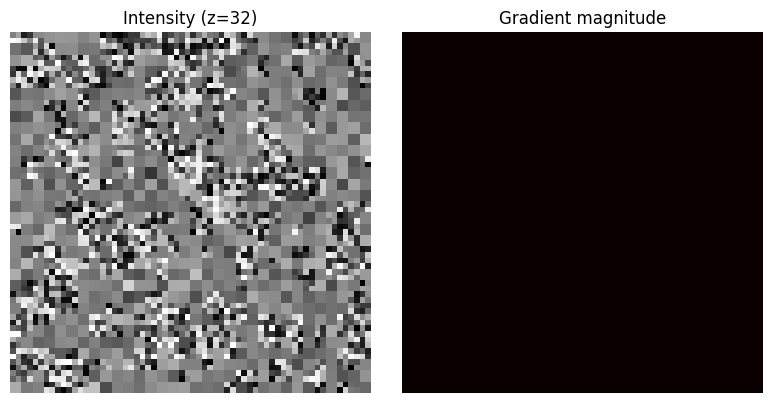

In [7]:
# Visualise gradient magnitude reconstruction
gm_recon = pyapr.reconstruction.reconstruct_constant(apr, gm)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(recon_const[32], cmap='gray');  axes[0].set_title('Intensity (z=32)')
axes[1].imshow(gm_recon[32],    cmap='hot');   axes[1].set_title('Gradient magnitude')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 7. I/O

In [8]:
with tempfile.TemporaryDirectory() as tmpdir:
    fpath = os.path.join(tmpdir, "test.apr")
    pyapr.io.write(fpath, apr, parts)
    print(f"Written to: {fpath}")

    apr2, parts2 = pyapr.io.read(fpath)
    print(f"Read back  particles: {apr2.total_number_particles()}")
    assert apr2.total_number_particles() == apr.total_number_particles(), "Particle count mismatch!"
    print("Roundtrip OK")

Written to: /var/folders/v_/7mhfqnhs3d76987qq5hjcz2c0000gn/T/tmpszmm4igq/test.apr
Read back  particles: 140120
Roundtrip OK


## 8. Morphology

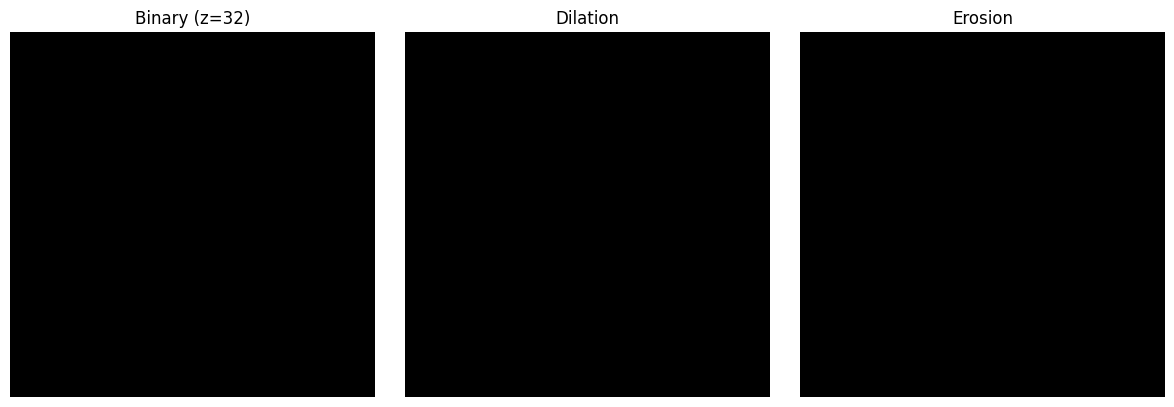

In [9]:
bin_parts = pyapr.ShortParticles((parts[:] > 500).astype(np.int16))
dilated   = pyapr.morphology.dilation(apr, bin_parts, radius=1)
eroded    = pyapr.morphology.erosion(apr,  bin_parts, radius=1)

bin_recon  = pyapr.reconstruction.reconstruct_constant(apr, bin_parts)
dil_recon  = pyapr.reconstruction.reconstruct_constant(apr, dilated)
ero_recon  = pyapr.reconstruction.reconstruct_constant(apr, eroded)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(bin_recon[32], cmap='gray'); axes[0].set_title('Binary (z=32)')
axes[1].imshow(dil_recon[32], cmap='gray'); axes[1].set_title('Dilation')
axes[2].imshow(ero_recon[32], cmap='gray'); axes[2].set_title('Erosion')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Measure

In [10]:
labels = pyapr.ShortParticles(bin_parts[:])
cc = pyapr.measure.connected_component(apr, labels)
print(f"Number of connected components: {int(cc[:].max())}")

Number of connected components: 1


## 10. Transform — maximum projection

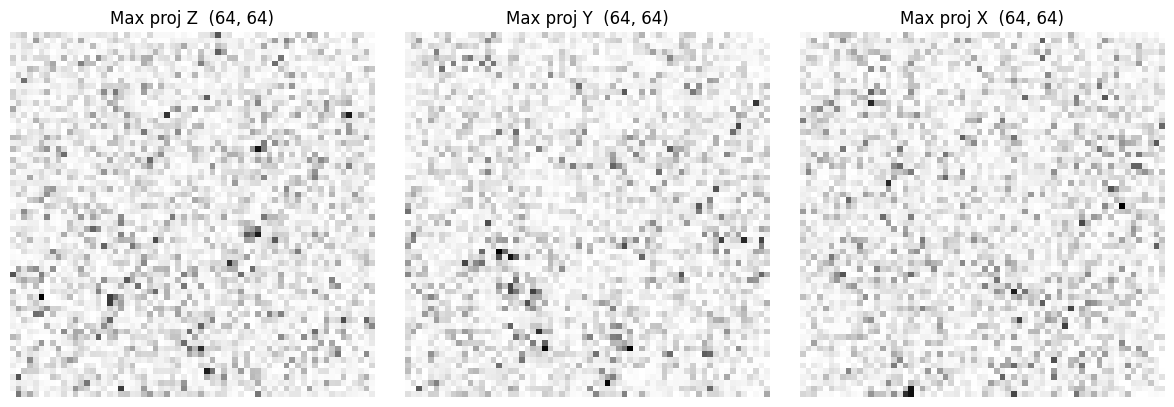

In [11]:
proj_z = pyapr.transform.maximum_projection(apr, parts, dim=0)
proj_y = pyapr.transform.maximum_projection(apr, parts, dim=1)
proj_x = pyapr.transform.maximum_projection(apr, parts, dim=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(proj_z, cmap='gray'); axes[0].set_title(f'Max proj Z  {proj_z.shape}')
axes[1].imshow(proj_y, cmap='gray'); axes[1].set_title(f'Max proj Y  {proj_y.shape}')
axes[2].imshow(proj_x, cmap='gray'); axes[2].set_title(f'Max proj X  {proj_x.shape}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Summary

In [12]:
tests = [
    "import pyapr",
    "synthetic image (64x64x64 uint16)",
    "converter.get_apr",
    "tree.fill_tree_mean",
    "reconstruction.reconstruct_constant",
    "reconstruction.reconstruct_smooth",
    "filter.gradient + gradient_magnitude + convolve",
    "io.write + io.read (roundtrip)",
    "morphology.dilation + erosion",
    "measure.connected_component",
    "transform.maximum_projection",
]
print("All smoke tests passed!")
for i, t in enumerate(tests, 1):
    print(f"  [{i:2d}] {t}")

All smoke tests passed!
  [ 1] import pyapr
  [ 2] synthetic image (64x64x64 uint16)
  [ 3] converter.get_apr
  [ 4] tree.fill_tree_mean
  [ 5] reconstruction.reconstruct_constant
  [ 6] reconstruction.reconstruct_smooth
  [ 7] filter.gradient + gradient_magnitude + convolve
  [ 8] io.write + io.read (roundtrip)
  [ 9] morphology.dilation + erosion
  [10] measure.connected_component
  [11] transform.maximum_projection
